Импорты, настройка графиков и загрузка датасета

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12
rcParams['figure.figsize'] = (12, 8)
rcParams['axes.titlesize'] = 16
rcParams['axes.labelsize'] = 14
rcParams['savefig.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'

df = pd.read_csv('../data/final/ai_publics_dataset.csv', encoding='utf-8')
df['post_datetime'] = pd.to_datetime(df['post_datetime'])

os.makedirs('figures', exist_ok=True)

Описание датасета: размер, период, доли постов, пропуски

In [3]:
n_channels = df['channel_username'].nunique()
n_posts = len(df)
time_span = (df['post_datetime'].max() - df['post_datetime'].min()).days
mean_posts_per_channel = n_posts / n_channels
n_features = df.shape[1]
scheduled_posts_pct = df['is_scheduled'].mean() * 100
media_posts_pct = (df['has_media'] == 1).mean() * 100
poll_posts_pct = (df['has_poll'] == 1).mean() * 100
missing_rates = df.isnull().mean() * 100

print(f"Каналов: {n_channels}, постов: {n_posts:,}, признаков: {n_features}")
print(f"Период: {time_span} дней, постов на канал в среднем: {mean_posts_per_channel:.0f}")
print(f"Отложенных: {scheduled_posts_pct:.1f}%, с медиа: {media_posts_pct:.1f}%, с опросами: {poll_posts_pct:.1f}%")
print(f"Максимальная доля пропусков в признаке: {missing_rates.max():.2f}%")

stats_table = pd.DataFrame({
    'Параметр': ['Количество каналов', 'Количество постов', 'Временной охват (дни)',
                 'Среднее число постов на канал', 'Количество признаков',
                 'Доля отложенных постов (%)', 'Доля постов с медиа (%)',
                 'Доля постов с опросами (%)'],
    'Значение': [n_channels, n_posts, time_span, mean_posts_per_channel,
                 n_features, scheduled_posts_pct, media_posts_pct, poll_posts_pct]
})
stats_table.to_csv('../docs/dataset_statistics.csv', index=False, encoding='utf-8-sig')

Каналов: 10, постов: 10,479, признаков: 83
Период: 364 дней, постов на канал в среднем: 1048
Отложенных: 1.9%, с медиа: 85.8%, с опросами: 1.1%
Максимальная доля пропусков в признаке: 0.00%


Публикационная активность: дни недели, часы, самые активные каналы

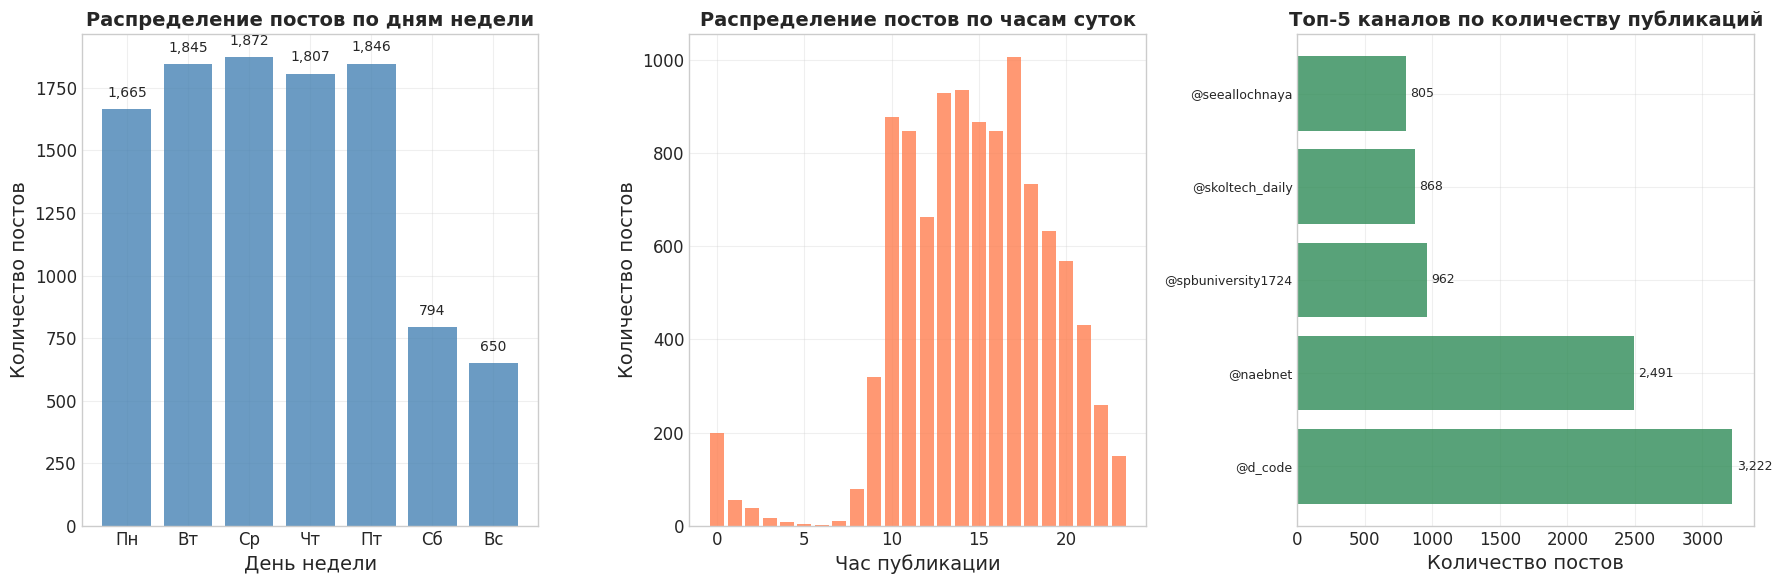

Самый активный день: Ср (1,872 постов)
Самый активный час: 17:00 (1,005 постов)
Самый активный канал: @d_code (3,222 постов)
Доля топ-5 каналов: 79.7% постов


In [4]:
df['post_day_of_week'] = df['post_datetime'].dt.dayofweek
df['post_hour'] = df['post_datetime'].dt.hour

weekday_counts = df['post_day_of_week'].value_counts().sort_index()
weekday_counts.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
hour_counts = df['post_hour'].value_counts().sort_index()
channel_activity = df['channel_username'].value_counts().head(5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].bar(weekday_counts.index, weekday_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Распределение постов по дням недели', fontsize=14, fontweight='bold')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество постов')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(weekday_counts.values):
    axes[0].text(i, v + max(weekday_counts.values) * 0.02, f'{v:,}',
                 ha='center', va='bottom', fontsize=10)

axes[1].bar(hour_counts.index, hour_counts.values, color='coral', alpha=0.8)
axes[1].set_title('Распределение постов по часам суток', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Час публикации')
axes[1].set_ylabel('Количество постов')
axes[1].grid(True, alpha=0.3)

y_pos = np.arange(len(channel_activity))
axes[2].barh(y_pos, channel_activity.values, color='seagreen', alpha=0.8)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels([f'@{name}' for name in channel_activity.index], fontsize=9)
axes[2].set_title('Топ-5 каналов по количеству публикаций', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Количество постов')
axes[2].grid(True, alpha=0.3)
for i, v in enumerate(channel_activity.values):
    axes[2].text(v + max(channel_activity.values) * 0.01, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/publication_activity.png', dpi=300)
plt.show()

print(f"Самый активный день: {weekday_counts.idxmax()} ({weekday_counts.max():,} постов)")
print(f"Самый активный час: {hour_counts.idxmax()}:00 ({hour_counts.max():,} постов)")
print(f"Самый активный канал: @{channel_activity.index[0]} ({channel_activity.values[0]:,} постов)")
print(f"Доля топ-5 каналов: {channel_activity.sum() / n_posts * 100:.1f}% постов")

Метрики вовлеченности: распределения, топ реакций, тональность, корреляции

          views  total_reactions  forwards
mean  70944.550          508.251   571.314
std   93151.585          939.551  1116.366


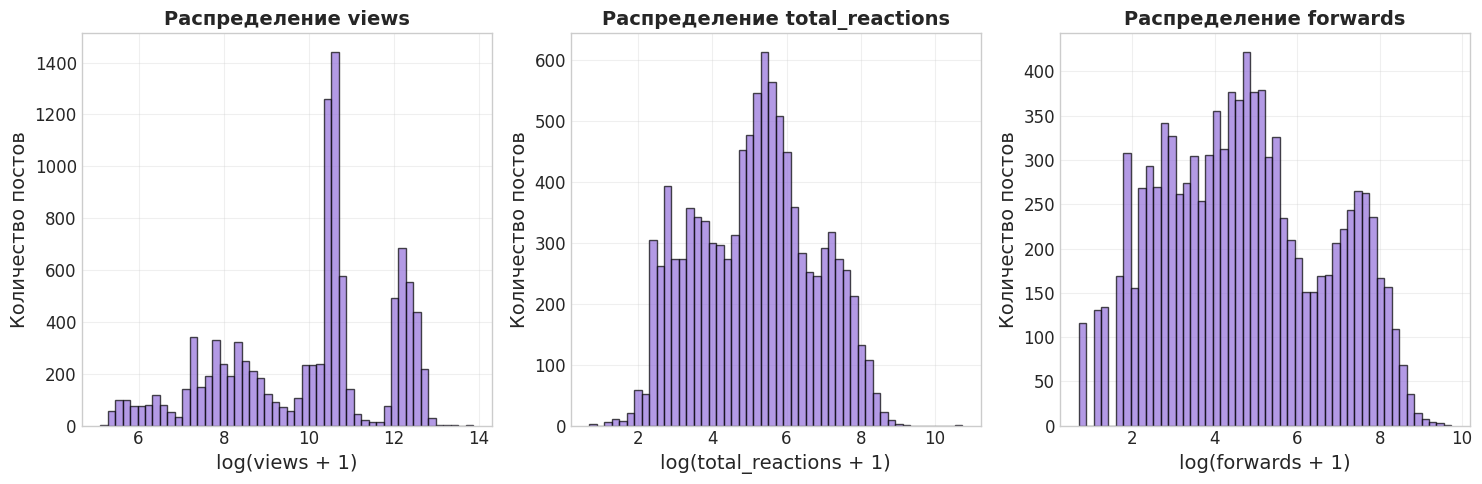


Всего реакций: 5,353,586, типов: 63
 1. ❤️ red_heart         1,336,300  25.0%
 2. 👍 thumbs_up         1,228,544  22.9%
 3. 🤯 exploding_head      784,970  14.7%
 4. 😁 grinning            585,956  10.9%
 5. 🔥 fire                369,021   6.9%
 6. 🤔 thinking            236,457   4.4%
 7. 🫡 saluting            183,581   3.4%
 8. 😡 pouting             168,753   3.2%
 9. 🤣 rofl                160,027   3.0%
10. 👀 eyes                 83,406   1.6%
11. 👎 thumbs_down          56,689   1.1%
12. 👾 alien                56,314   1.1%
13. 🚫 prohibited           15,116   0.3%
14. 🤡 clown                12,489   0.2%
15. 🤩 star_struck           9,664   0.2%


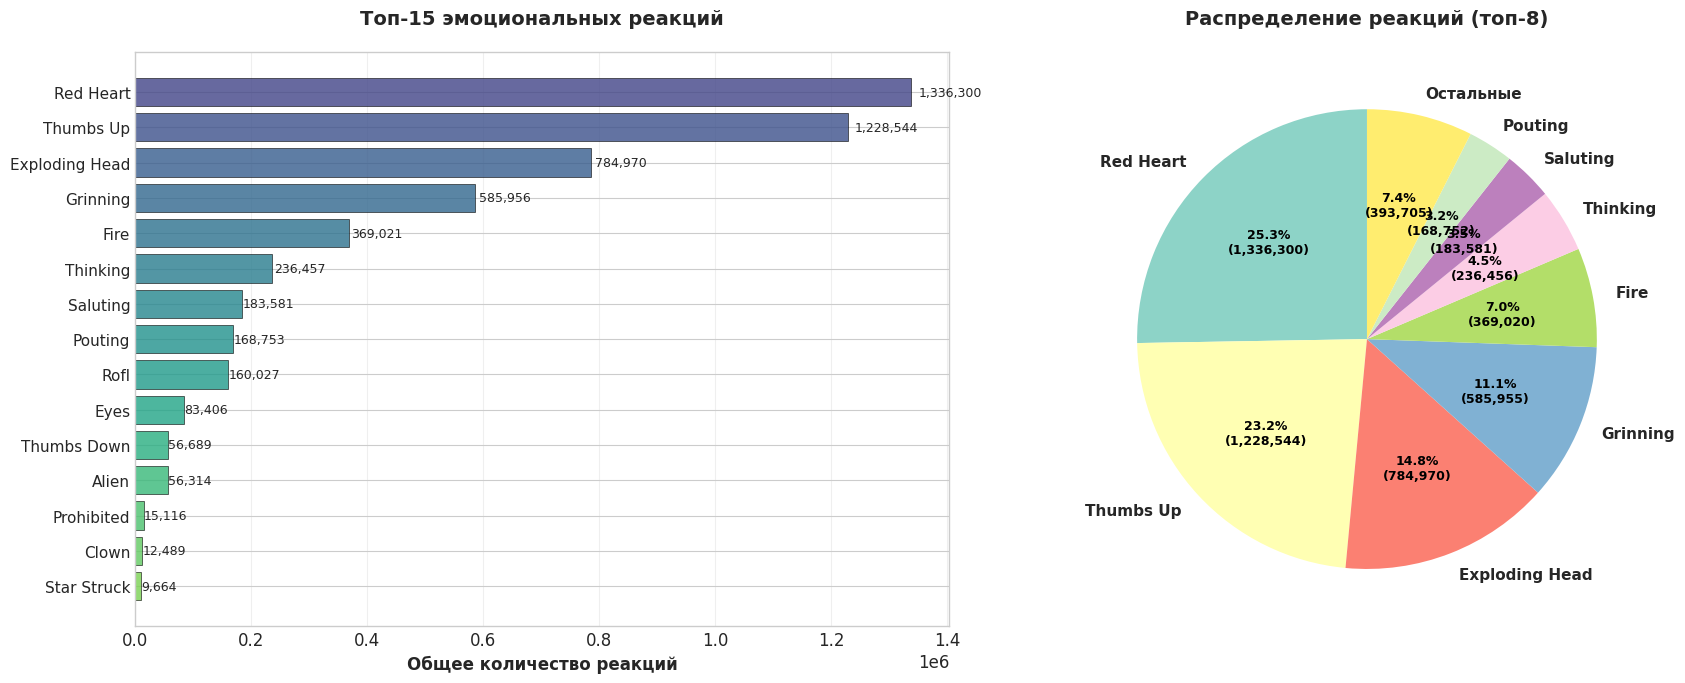

Позитивные: 3,547,899 (66.3%)
Негативные: 255,200 (4.8%)
Нейтральные: 320,078 (6.0%)
Прочие: 1,230,409 (23.0%)


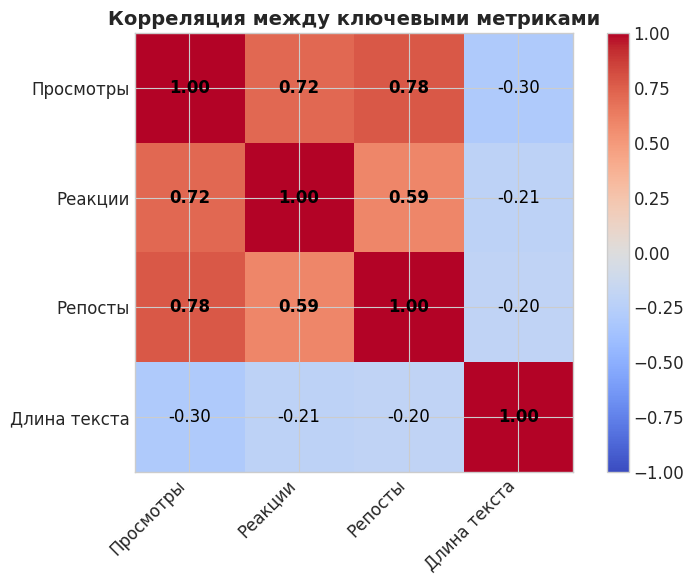

In [5]:
# Названия эмодзи для подписей на графиках
emoji_to_text = {
    '☃': 'snowman',
    '⚡': 'lightning',
    '✍': 'writing_hand',
    '🆒': 'cool',
    '🍾': 'champagne',
    '🎄': 'christmas_tree',
    '🎅': 'santa',
    '🎉': 'tada',
    '🏆': 'trophy',
    '🐳': 'whale',
    '👀': 'eyes',
    '👌': 'ok_hand',
    '👍': 'thumbs_up',
    '👏': 'clap',
    '👨‍💻': 'technologist',
    '💯': 'hundred',
    '🔥': 'fire',
    '🕊': 'dove',
    '😁': 'grinning',
    '😍': 'heart_eyes',
    '😎': 'sunglasses',
    '😘': 'kissing_heart',
    '🙏': 'pray',
    '🤓': 'nerd',
    '🤔': 'thinking',
    '🤝': 'handshake',
    '🤩': 'star_struck',
    '🥰': 'smiling_hearts',
    '🦄': 'unicorn',
    '🫡': 'saluting',
    '❤️': 'red_heart',
    '⭐': 'star',
    '🎃': 'pumpkin',
    '👾': 'alien',
    '💅': 'nail_polish',
    '🗿': 'moai',
    '😐': 'neutral',
    '😢': 'crying',
    '😨': 'fearful',
    '😱': 'screaming',
    '😴': 'sleeping',
    '🙊': 'speak_no_evil',
    '🤖': 'robot',
    '🤗': 'hugging',
    '🤪': 'zany',
    '🤯': 'exploding_head',
    '🥱': 'yawning',
    '🧑‍🎓': 'student',
    '👎': 'thumbs_down',
    '😡': 'pouting',
    '🤣': 'rofl',
    '🌚': 'new_moon_face',
    '👻': 'ghost',
    '🔦': 'flashlight',
    '🗣': 'speaking_head',
    '💔': 'broken_heart',
    '💩': 'poop',
    '😈': 'smiling_devil',
    '😭': 'sobbing',
    '🚫': 'prohibited',
    '🤡': 'clown',
    '🥹': 'tearing_up',
    '😇': 'angel'
}

engagement_metrics = ['views', 'total_reactions', 'forwards']
print(df[engagement_metrics].agg(['mean', 'std']).round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, engagement_metrics):
    ax.hist(np.log1p(df[metric][df[metric] > 0]), bins=50, alpha=0.7,
            color='mediumpurple', edgecolor='black')
    ax.set_title(f'Распределение {metric}', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'log({metric} + 1)')
    ax.set_ylabel('Количество постов')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/engagement_distribution.png', dpi=300)
plt.show()

reaction_cols = [col for col in df.columns if col.startswith('reaction_')]
reaction_sums = df[reaction_cols].sum().sort_values(ascending=False).head(15)
total_reactions = df[reaction_cols].sum().sum()
emojis = [col.replace('reaction_', '') for col in reaction_sums.index]
names = [emoji_to_text.get(e, 'unknown') for e in emojis]

print(f"\nВсего реакций: {total_reactions:,.0f}, типов: {len(reaction_cols)}")
for i, (e, name, total) in enumerate(zip(emojis, names, reaction_sums.values), 1):
    print(f"{i:>2}. {e} {name:<16} {total:>10,.0f} {total / total_reactions:>6.1%}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

y_pos = np.arange(len(reaction_sums))
bars = axes[0].barh(y_pos, reaction_sums.values,
                    color=plt.cm.viridis(np.linspace(0.2, 0.8, len(y_pos))),
                    alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([n.replace('_', ' ').title() for n in names], fontsize=11)
axes[0].set_xlabel('Общее количество реакций', fontsize=12, fontweight='bold')
axes[0].set_title('Топ-15 эмоциональных реакций', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()
for bar, value in zip(bars, reaction_sums.values):
    width = bar.get_width()
    axes[0].text(width * 1.01, bar.get_y() + bar.get_height() / 2,
                 f'{value:,.0f}', ha='left', va='center', fontsize=9)

top_n = 8
pie_labels = [n.replace('_', ' ').title()[:15] for n in names[:top_n]]
pie_values = list(reaction_sums.values[:top_n])
other_sum = reaction_sums.values[top_n:].sum()
if other_sum > 0:
    pie_labels.append('Остальные')
    pie_values.append(other_sum)

wedges, texts, autotexts = axes[1].pie(
    pie_values, labels=pie_labels, colors=plt.cm.Set3(np.linspace(0, 1, len(pie_values))),
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct / 100 * sum(pie_values)):,})',
    startangle=90, textprops={'fontsize': 10})
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
axes[1].set_title(f'Распределение реакций (топ-{top_n})', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('figures/top_reactions.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# Грубая разметка, список неполный
positive_emojis = ['👍', '❤️', '🔥', '😍', '🎉', '👏', '🥰', '🤩', '😁', '👌', '🏆']
negative_emojis = ['👎', '😡', '😢', '💔', '😭', '🚫', '🤡']
neutral_emojis = ['🤔', '😐', '👀', '😴', '🗿']

sums = df[reaction_cols].sum()
sums.index = [c.replace('reaction_', '') for c in sums.index]
positive = sums[sums.index.isin(positive_emojis)].sum()
negative = sums[sums.index.isin(negative_emojis)].sum()
neutral = sums[sums.index.isin(neutral_emojis)].sum()
other = sums.sum() - positive - negative - neutral
for name, value in [('Позитивные', positive), ('Негативные', negative),
                    ('Нейтральные', neutral), ('Прочие', other)]:
    print(f"{name}: {value:,.0f} ({value / sums.sum():.1%})")

numeric_cols = ['views', 'total_reactions', 'forwards', 'text_length']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
tick_labels = ['Просмотры', 'Реакции', 'Репосты', 'Длина текста']
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.set_yticklabels(tick_labels)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black',
                fontweight='bold' if abs(corr.iloc[i, j]) > 0.5 else 'normal')
ax.set_title('Корреляция между ключевыми метриками', fontsize=14, fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=300)
plt.show()